In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [3]:
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers = tickers_yfinance,
    start="2023-01-01",
    end="2023-12-31",
    auto_adjust=True
)

df_fechamento  = dados_brutos['Close'].copy()
df_fechamento  = df_fechamento.ffill()        # ffill no fechamento
df_consolidado = np.log(df_fechamento)        # log em cima do ffill

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]
df_consolidado.index   = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Período : {df_consolidado.index[0]} → {df_consolidado.index[-1]}")
print(f"Matriz  : {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")
df_consolidado

[*********************100%***********************]  50 of 50 completed


--- Processamento Concluído ---
Período : 2023-01-02 → 2023-12-28
Matriz  : 248 dias x 50 ações.


,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,...,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,2.484676,2.557374,3.569516,2.392025,2.581533,2.385907,3.141535,3.022362,3.561405,0.701410,...,3.814663,3.233165,2.156384,3.203251,2.343053,1.869003,4.198958,2.419394,2.690460,3.550844
2023-01-03,2.483266,2.513425,3.550615,2.357983,2.562716,2.335008,3.109893,2.973371,3.512725,0.664369,...,3.832269,3.222620,2.131879,3.168270,2.327026,1.857558,4.197167,2.389005,2.670196,3.525594
2023-01-04,2.488896,2.523007,3.577125,2.365555,2.575502,2.337862,3.114827,3.004782,3.518762,0.723883,...,3.834273,3.221441,2.149684,3.197052,2.350557,1.877502,4.198958,2.418032,2.691833,3.532301
2023-01-05,2.491699,2.554914,3.579079,2.396098,2.620164,2.380391,3.116978,3.044620,3.584213,0.750200,...,3.840460,3.225560,2.140397,3.241521,2.363758,1.935052,4.215598,2.422789,2.718371,3.534437
2023-01-06,2.493796,2.583444,3.579567,2.419402,2.633953,2.407993,3.145720,3.050323,3.601249,0.767368,...,3.834073,3.263300,2.153039,3.257745,2.375168,1.945648,4.231315,2.429546,2.739525,3.549005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-21,2.500484,3.076587,3.600587,2.585696,3.155687,2.610749,3.237725,3.541501,3.255612,2.014645,...,3.943650,3.399745,2.676205,3.470521,3.151236,2.177657,4.131088,2.860577,3.107943,3.521053
2023-12-22,2.501214,3.069040,3.609442,2.587075,3.158446,2.625651,3.244040,3.545313,3.256369,1.994891,...,3.952609,3.406947,2.685222,3.455415,3.152758,2.193953,4.123524,2.867710,3.115061,3.524345
2023-12-26,2.505581,3.077714,3.612297,2.597360,3.167589,2.628618,3.251506,3.558540,3.258260,1.970915,...,3.957693,3.409072,2.682984,3.475904,3.155416,2.198254,4.127053,2.878671,3.120087,3.530080


In [ ]:
# Criando a matriz de correlação

matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,CMIG4,CPFE3,CSAN3,CSMG3,CURY3,CYRE3,DIRR3,EGIE3,ENEV3,ENGI11,EQTL3,GGBR4,HAPV3,HYPE3,ITSA4,ITUB4,KLBN11,LREN3,MBRF3,MGLU3,MULT3,PETR4,PRIO3,PSSA3,RADL3,RAIL3,RDOR3,RENT3,SANB11,SBSP3,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
ABEV3,1.00,0.21,0.23,0.58,0.08,0.50,-0.55,0.15,-0.27,0.15,0.25,0.08,0.31,0.52,0.07,0.20,0.28,0.39,0.31,0.21,0.12,0.20,-0.10,0.44,0.24,0.15,-0.06,0.59,0.09,0.48,0.43,-0.14,-0.39,0.05,0.38,0.19,0.47,0.64,0.33,-0.20,-0.49,0.38,0.12,0.24,0.06,0.43,-0.29,-0.20,-0.08,0.47
ALOS3,0.21,1.00,0.45,0.75,0.94,0.85,-0.38,0.97,-0.36,0.96,0.73,0.90,0.83,0.88,0.93,0.94,0.90,0.92,0.60,0.94,0.96,-0.30,0.54,-0.21,0.93,0.89,0.86,-0.19,0.40,-0.52,0.80,0.91,0.67,0.78,0.93,0.95,0.48,0.71,0.61,0.75,0.52,0.59,0.89,0.50,0.93,0.27,-0.64,0.84,0.79,-0.52
AXIA3,0.23,0.45,1.00,0.67,0.35,0.65,-0.17,0.48,0.26,0.43,0.20,0.52,0.65,0.33,0.40,0.34,0.36,0.33,0.74,0.55,0.49,0.33,0.69,0.17,0.61,0.63,0.34,0.34,0.79,-0.11,0.21,0.36,0.38,0.39,0.40,0.30,0.58,0.46,0.75,0.56,0.39,0.49,0.28,0.69,0.40,0.71,0.19,0.51,0.45,-0.34
B3SA3,0.58,0.75,0.67,1.00,0.59,0.92,-0.54,0.74,-0.04,0.70,0.55,0.64,0.86,0.75,0.66,0.75,0.74,0.74,0.81,0.74,0.70,0.22,0.59,0.31,0.77,0.68,0.58,0.40,0.51,0.02,0.60,0.51,0.37,0.54,0.79,0.70,0.83,0.90,0.67,0.46,0.21,0.63,0.52,0.56,0.57,0.58,-0.43,0.49,0.43,-0.11
BBAS3,0.08,0.94,0.35,0.59,1.00,0.74,-0.18,0.92,-0.46,0.93,0.68,0.87,0.68,0.83,0.88,0.88,0.82,0.89,0.47,0.89,0.92,-0.47,0.42,-0.40,0.91,0.90,0.81,-0.34,0.35,-0.60,0.82,0.94,0.66,0.78,0.88,0.89,0.29,0.58,0.58,0.77,0.52,0.59,0.94,0.47,0.95,0.24,-0.60,0.85,0.87,-0.58
BBDC4,0.50,0.85,0.65,0.92,0.74,1.00,-0.49,0.83,-0.23,0.80,0.55,0.72,0.81,0.86,0.72,0.78,0.75,0.85,0.75,0.82,0.79,-0.05,0.53,0.07,0.88,0.84,0.66,0.22,0.53,-0.19,0.74,0.65,0.40,0.61,0.87,0.76,0.68,0.83,0.81,0.61,0.33,0.73,0.70,0.63,0.75,0.58,-0.46,0.65,0.63,-0.27
BBSE3,-0.55,-0.38,-0.17,-0.54,-0.18,-0.49,1.00,-0.32,0.09,-0.30,-0.33,-0.13,-0.39,-0.49,-0.24,-0.32,-0.32,-0.42,-0.16,-0.27,-0.25,-0.07,-0.20,-0.35,-0.23,-0.13,-0.33,-0.31,0.01,-0.08,-0.21,-0.13,0.08,-0.11,-0.44,-0.39,-0.51,-0.50,-0.22,0.03,0.09,-0.12,-0.17,-0.03,-0.17,0.04,0.54,-0.08,0.07,-0.00
BPAC11,0.15,0.97,0.48,0.74,0.92,0.83,-0.32,1.00,-0.33,0.95,0.73,0.94,0.85,0.84,0.93,0.94,0.89,0.87,0.63,0.95,0.97,-0.28,0.58,-0.27,0.95,0.90,0.89,-0.26,0.46,-0.60,0.71,0.93,0.75,0.76,0.90,0.94,0.46,0.65,0.58,0.80,0.61,0.50,0.90,0.46,0.93,0.27,-0.59,0.85,0.80,-0.55
BRAV3,-0.27,-0.36,0.26,-0.04,-0.46,-0.23,0.09,-0.33,1.00,-0.43,-0.24,-0.34,0.02,-0.57,-0.31,-0.33,-0.34,-0.52,0.11,-0.33,-0.32,0.74,0.42,0.51,-0.33,-0.34,-0.19,0.38,0.00,0.35,-0.58,-0.34,0.12,-0.22,-0.43,-0.38,0.33,-0.11,-0.09,-0.26,-0.01,-0.29,-0.61,-0.09,-0.50,-0.00,0.43,-0.26,-0.46,0.09
CEAB3,0.15,0.96,0.43,0.70,0.93,0.80,-0.30,0.95,-0.43,1.00,0.64,0.91,0.76,0.85,0.93,0.92,0.89,0.89,0.60,0.93,0.95,-0.37,0.47,-0.33,0.92,0.88,0.83,-0.24,0.51,-0.56,0.78,0.91,0.66,0.72,0.89,0.92,0.37,0.63,0.59,0.80,0.57,0.60,0.91,0.56,0.95,0.33,-0.56,0.87,0.85,-0.54


In [ ]:
# Cria uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeitamos H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

,Ativo,p-valor (Nível),Estacionária em Nível?,p-valor (1ª Dif),Estacionária em 1ª Dif?,Ordem de Integração
0,ABEV3,0.3207,Não,0.0000,Sim,I(1) - Integrada de ordem 1
1,ALOS3,0.8815,Não,0.0000,Sim,I(1) - Integrada de ordem 1
2,AXIA3,0.4891,Não,0.0000,Sim,I(1) - Integrada de ordem 1
3,B3SA3,0.5850,Não,0.0000,Sim,I(1) - Integrada de ordem 1
4,BBAS3,0.3675,Não,0.0000,Sim,I(1) - Integrada de ordem 1
5,BBDC4,0.7568,Não,0.0000,Sim,I(1) - Integrada de ordem 1
6,BBSE3,0.2621,Não,0.0000,Sim,I(1) - Integrada de ordem 1
7,BPAC11,0.9170,Não,0.0000,Sim,I(1) - Integrada de ordem 1
8,BRAV3,0.4046,Não,0.0000,Sim,I(1) - Integrada de ordem 1
9,CEAB3,0.7007,Não,0.0000,Sim,I(1) - Integrada de ordem 1


In [6]:
cesta_definitiva = df_consolidado.drop(columns=[])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.3207,0.0920,0.0000,0.1000
1,ALOS3,0.8815,0.0100,0.0000,0.1000
2,AXIA3,0.4891,0.0992,0.0000,0.1000
3,B3SA3,0.5850,0.0174,0.0000,0.1000
4,BBAS3,0.3675,0.0100,0.0000,0.1000
5,BBDC4,0.7568,0.0100,0.0000,0.1000
6,BBSE3,0.2621,0.1000,0.0000,0.1000
7,BPAC11,0.9170,0.0100,0.0000,0.1000
8,BRAV3,0.4046,0.0136,0.0000,0.1000
9,CEAB3,0.7007,0.0100,0.0000,0.1000


In [7]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['ABEV3', 'BBSE3', 'USIM5', 'RDOR3', 'AXIA3'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

Pares cointegrados encontrados: 68
Ativos na cesta do Johansen: 45


,Ativo 1,Ativo 2,Estatística Traço,V.C. Traço (95%),Rejeita r=0 (Traço)?,Estatística Max-Eigen,V.C. Max-Eigen (95%),Rejeita r=0 (Eigen)?,Beta (Ativo 2)
0,CSMG3,RADL3,25.90,15.49,Sim,25.03,14.26,Sim,-1.6705
1,CSMG3,MULT3,25.54,15.49,Sim,23.95,14.26,Sim,-2.6678
2,SANB11,TAEE11,25.50,15.49,Sim,23.46,14.26,Sim,-1.9804
3,MBRF3,TOTS3,22.98,15.49,Sim,22.34,14.26,Sim,-1.7110
4,BRAV3,MULT3,21.85,15.49,Sim,18.51,14.26,Sim,2.3563
...,...,...,...,...,...,...,...,...,...
63,ENGI11,ITSA4,15.16,15.49,Não,15.14,14.26,Sim,-1.0942
64,MULT3,SBSP3,15.09,15.49,Não,15.09,14.26,Sim,-0.1408
65,PSSA3,VBBR3,15.09,15.49,Não,14.37,14.26,Sim,-0.4559
66,MULT3,UGPA3,14.91,15.49,Não,14.89,14.26,Sim,-0.2089


In [8]:
resultados_meia_vida = []

for _, linha in df_pares_cointegrados.iterrows():
    at1  = linha['Ativo 1']
    at2  = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']

    try:
        spread  = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread  = spread.dropna()

        df_reg  = pd.DataFrame({
            'Y': spread.diff(),
            'X': spread.shift(1)
        }).dropna()

        modelo      = sm.OLS(df_reg['Y'], sm.add_constant(df_reg['X'])).fit()
        lambda_coef = modelo.params['X']

        hl = np.round(-np.log(2) / lambda_coef, 2) if lambda_coef < 0 else 'Divergente'

        resultados_meia_vida.append({
            'Par'                   : f"{at1} x {at2}",
            'Valor do Lambda'       : np.round(lambda_coef, 6),
            'Meia-Vida (Dias Úteis)': hl
        })
    except Exception:
        continue

df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
df_estatistica_pares['_ord'] = pd.to_numeric(
    df_estatistica_pares['Meia-Vida (Dias Úteis)'], errors='coerce')
df_estatistica_pares = (df_estatistica_pares
                        .sort_values('_ord')
                        .drop(columns='_ord')
                        .reset_index(drop=True))

print(f"Meia-vida calculada para {len(df_estatistica_pares)} pares.")
df_estatistica_pares

Meia-vida calculada para 68 pares.


,Par,Valor do Lambda,Meia-Vida (Dias Úteis)
0,ENEV3 x MULT3,-0.036217,19.14
1,VALE3 x WEGE3,-0.035283,19.65
2,CSAN3 x MULT3,-0.031712,21.86
3,B3SA3 x MULT3,-0.030634,22.63
4,MULT3 x SBSP3,-0.029422,23.56
...,...,...,...
63,BPAC11 x EQTL3,-0.002816,246.17
64,BPAC11 x ENGI11,-0.002758,251.34
65,ENGI11 x ITSA4,-0.002113,327.96
66,MGLU3 x PETR4,-0.001685,411.28


In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Define lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS PARES
# ==============================================================================
resultados_hurst = []

print(f"Calculando o Expoente de Hurst para {len(df_pares_cointegrados)} pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Spread: S_t = P1_t - beta * P2_t  
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

Calculando o Expoente de Hurst para 68 pares...


,Par,Estatística Traço,Beta,Expoente de Hurst (H)
0,CMIG4 x HAPV3,18.22,-0.0861,0.2419
1,CPFE3 x EQTL3,15.27,-0.9313,0.3287
2,VALE3 x WEGE3,16.78,6.9568,0.3349
3,CMIG4 x KLBN11,20.22,-0.5987,0.3367
4,MGLU3 x PETR4,15.40,1.2343,0.3396
...,...,...,...,...
63,CSMG3 x MULT3,25.54,-2.6678,0.6167
64,HYPE3 x LREN3,20.39,-0.6527,0.6216
65,B3SA3 x HAPV3,15.55,-0.4588,0.6315
66,CSMG3 x RADL3,25.90,-1.6705,0.6433


In [ ]:
# 1. Cria uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()


df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 2. Isola as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 3. Faz o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 4. Reorganiza a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 5. Ordena o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,CMIG4 x HAPV3,CMIG4,HAPV3,18.22,12.96,-0.0861,28.43,0.2419
1,CPFE3 x EQTL3,CPFE3,EQTL3,15.27,14.39,-0.9313,142.16,0.3287
2,VALE3 x WEGE3,VALE3,WEGE3,16.78,10.72,6.9568,19.65,0.3349
3,CMIG4 x KLBN11,CMIG4,KLBN11,20.22,16.84,-0.5987,50.29,0.3367
4,MGLU3 x PETR4,MGLU3,PETR4,15.40,14.76,1.2343,411.28,0.3396
...,...,...,...,...,...,...,...,...
63,CSMG3 x MULT3,CSMG3,MULT3,25.54,23.95,-2.6678,38.65,0.6167
64,HYPE3 x LREN3,HYPE3,LREN3,20.39,15.50,-0.6527,45.1,0.6216
65,B3SA3 x HAPV3,B3SA3,HAPV3,15.55,11.59,-0.4588,37.32,0.6315
66,CSMG3 x RADL3,CSMG3,RADL3,25.90,25.03,-1.6705,103.54,0.6433


In [ ]:
# ==============================================================================
# FILTRAGEM DO GRUPO DOS PARES PARA BACKTEST
# ==============================================================================

# 1. Garante que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplica as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 30 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50
#condicao_beta  = df_ultimo['Beta (Ativo 2)'].abs() <= 10

# 3. Cria o DataFrame filtrado com os pares eleitos (os seus "Pares Verdes")
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordena pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

Sucesso! Foram selecionados 10 pares que cumprem todos os requisitos rigorosos.


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,CMIG4 x HAPV3,CMIG4,HAPV3,18.22,12.96,-0.0861,28.43,0.2419
1,VALE3 x WEGE3,VALE3,WEGE3,16.78,10.72,6.9568,19.65,0.3349
2,CPFE3 x MULT3,CPFE3,MULT3,17.03,16.28,-2.9141,27.71,0.4294
3,ENEV3 x SANB11,ENEV3,SANB11,16.81,12.48,-0.7186,28.24,0.4465
4,CSAN3 x MULT3,CSAN3,MULT3,15.58,12.66,-5.9213,21.86,0.4773
5,ENEV3 x MULT3,ENEV3,MULT3,15.56,11.05,121.7173,19.14,0.4801
6,CYRE3 x MULT3,CYRE3,MULT3,16.53,13.12,-5.9743,26.18,0.4847
7,DIRR3 x MULT3,DIRR3,MULT3,18.35,15.24,-3.3294,27.55,0.4902
8,HYPE3 x MULT3,HYPE3,MULT3,15.91,14.33,2.8720,29.46,0.4903
9,GGBR4 x MULT3,GGBR4,MULT3,15.91,12.24,1.9987,28.25,0.4957


In [ ]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2023-01-01':'2023-12-31'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

,CMIG4 x HAPV3_Spread,CMIG4 x HAPV3_Z-Score,VALE3 x WEGE3_Spread,VALE3 x WEGE3_Z-Score,CPFE3 x MULT3_Spread,CPFE3 x MULT3_Z-Score,ENEV3 x SANB11_Spread,ENEV3 x SANB11_Z-Score,CSAN3 x MULT3_Spread,CSAN3 x MULT3_Z-Score,ENEV3 x MULT3_Spread,ENEV3 x MULT3_Z-Score,CYRE3 x MULT3_Spread,CYRE3 x MULT3_Z-Score,DIRR3 x MULT3_Spread,DIRR3 x MULT3_Z-Score,HYPE3 x MULT3_Spread,HYPE3 x MULT3_Z-Score,GGBR4 x MULT3_Spread,GGBR4 x MULT3_Z-Score
Date,,,,,,,,,,,,,,,,,,,,
2023-01-02,2.068611,-1.189460,-20.503556,0.200834,11.749739,-2.524059,4.640600,-1.062409,19.882442,-2.685885,-350.222284,2.944421,19.660129,-2.748748,10.978525,-2.533499,-4.680715,2.787910,-2.793552,2.600676
2023-01-03,2.042045,-1.502519,-20.329683,0.622051,11.642855,-2.889963,4.622178,-1.244326,19.648589,-3.145916,-346.295485,3.373807,19.421266,-3.132966,10.835369,-2.935820,-4.631881,2.976038,-2.726785,2.937414
2023-01-04,2.055503,-1.343924,-20.374550,0.513357,11.703428,-2.682598,4.674030,-0.732306,19.755188,-2.936216,-348.304829,3.154090,19.560069,-2.909698,10.871484,-2.834325,-4.676834,2.802863,-2.765148,2.743932
2023-01-05,2.068237,-1.193873,-20.372775,0.517657,11.780842,-2.417580,4.707912,-0.397731,19.930141,-2.592052,-351.463923,2.808650,19.742527,-2.616209,10.976343,-2.539629,-4.739124,2.562903,-2.793181,2.602549
2023-01-06,2.067330,-1.204564,-20.458404,0.310218,11.847172,-2.190508,4.781958,0.333454,20.120849,-2.216896,-354.622152,2.463305,19.945788,-2.289258,11.085109,-2.233955,-4.800713,2.325642,-2.838343,2.374776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-21,2.171317,0.020816,-20.364170,0.538503,13.079710,2.028934,4.963395,2.125076,22.216395,1.905424,-394.258087,-1.870796,22.495400,1.811861,12.549540,1.881653,-5.906031,-1.932409,-3.636360,-1.650005
2023-12-22,2.182767,0.155740,-20.394638,0.464695,13.054376,1.942207,4.976619,2.255659,22.170668,1.815470,-393.104021,-1.744601,22.457559,1.750991,12.534063,1.838157,-5.863164,-1.767270,-3.606939,-1.501623
2023-12-26,2.200866,0.369010,-20.431009,0.376584,13.040801,1.895734,4.975114,2.240796,22.153036,1.780784,-392.682546,-1.698514,22.434138,1.713319,12.516370,1.788435,-5.860024,-1.755173,-3.602050,-1.476966


In [13]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2024-01-01",
                          end="2024-06-30", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Parâmetros fixos da estimação ──────────────────────────────────────
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # ── Spread e Z-Score do trading com beta ESTÁTICO ─────────────────────
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (apenas informativo) ───────────────────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Verificação de sanidade do Kalman ──────────────────────────────────
        beta_max = np.abs(beta_dinamico).max()
        if beta_max > abs(beta_0) * 10:
            print(f"  [AVISO] {par_nome}: Kalman divergiu — beta máximo = {beta_max:.2f}  "
                  f"(beta Johansen = {beta_0:.4f})")

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"\nPeriodo de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading


Periodo de trading: 2024-01-02 → 2024-06-28
Dias úteis        : 124
Pares processados : 10


,CMIG4 x HAPV3_Beta_Kalman,CMIG4 x HAPV3_Spread,CMIG4 x HAPV3_Z-Score,VALE3 x WEGE3_Beta_Kalman,VALE3 x WEGE3_Spread,VALE3 x WEGE3_Z-Score,CPFE3 x MULT3_Beta_Kalman,CPFE3 x MULT3_Spread,CPFE3 x MULT3_Z-Score,ENEV3 x SANB11_Beta_Kalman,...,CYRE3 x MULT3_Z-Score,DIRR3 x MULT3_Beta_Kalman,DIRR3 x MULT3_Spread,DIRR3 x MULT3_Z-Score,HYPE3 x MULT3_Beta_Kalman,HYPE3 x MULT3_Spread,HYPE3 x MULT3_Z-Score,GGBR4 x MULT3_Beta_Kalman,GGBR4 x MULT3_Spread,GGBR4 x MULT3_Z-Score
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-02,0.326575,2.211103,0.489651,2.659824,-20.397458,0.457862,-0.006905,12.991949,1.728497,0.375056,...,1.499964,-0.536176,12.482624,1.693594,1.567143,-5.831268,-1.644399,1.198709,-3.575077,-1.340927
2024-01-03,0.335618,2.221493,0.612080,2.554676,-20.455726,0.316706,0.072224,13.012270,1.798063,0.404023,...,1.533780,-0.462319,12.483266,1.695400,1.529532,-5.858613,-1.749740,1.174821,-3.599055,-1.461859
2024-01-04,0.339097,2.214443,0.529004,2.520112,-20.376128,0.509534,0.099080,12.980185,1.688223,0.414249,...,1.388673,-0.438716,12.433657,1.555979,1.516983,-5.841257,-1.682880,1.167002,-3.586332,-1.397690
2024-01-05,0.340752,2.228184,0.690930,2.503380,-20.314017,0.660002,0.112724,12.994303,1.736555,0.420038,...,1.451022,-0.425755,12.463844,1.640816,1.511316,-5.835455,-1.660528,1.162738,-3.595225,-1.442541
2024-01-08,0.341966,2.249385,0.940763,2.492742,-20.336504,0.605527,0.120616,13.013452,1.802109,0.423690,...,1.581042,-0.416991,12.509342,1.768682,1.508566,-5.833059,-1.651295,1.160075,-3.604437,-1.489003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-24,0.374555,2.437833,3.161413,2.397820,-21.430260,-2.044154,0.133385,12.295474,-0.655800,0.432252,...,-0.493104,-0.368096,12.036766,0.440565,1.507623,-5.469648,-0.251318,1.170543,-3.283257,0.130861
2024-06-25,0.374918,2.436495,3.145641,2.396834,-21.552517,-2.340329,0.133241,12.265690,-0.757761,0.432265,...,-0.581147,-0.367897,12.021741,0.398337,1.507870,-5.436988,-0.125502,1.170819,-3.264650,0.224707
2024-06-26,0.375228,2.418785,2.936956,2.395832,-21.603532,-2.463915,0.133085,12.283933,-0.695311,0.432339,...,-0.549820,-0.367640,12.063064,0.514470,1.508044,-5.469243,-0.249757,1.171129,-3.258950,0.253455


In [14]:
DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Posição comprada: abriu quando z <= -2, fecha quando volta a 0 ───
        if estava_comprado:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_comprado = False
                total_trades += 1
            elif z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Posição vendida: abriu quando z >= +2, fecha quando volta a 0 ────
        if estava_vendido:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_vendido = False
                total_trades += 1
            elif z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

Varredura concluída! 10 pares analisados.


,Par,Hurst,Meia-Vida,Quantidade de Trades
0,CMIG4 x HAPV3,0.2419,28.43,4
1,VALE3 x WEGE3,0.3349,19.65,1
2,CPFE3 x MULT3,0.4294,27.71,1
3,ENEV3 x SANB11,0.4465,28.24,1
4,CSAN3 x MULT3,0.4773,21.86,1
5,ENEV3 x MULT3,0.4801,19.14,1
6,DIRR3 x MULT3,0.4902,27.55,1
7,HYPE3 x MULT3,0.4903,29.46,1
8,GGBR4 x MULT3,0.4957,28.25,1
9,CYRE3 x MULT3,0.4847,26.18,0


In [15]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

Par                               média      min      max      status
──────────────────────────────────────────────────────────────────────
CMIG4 x HAPV3                      1.68     0.13     3.35  ✗ DIVERGIU
VALE3 x WEGE3                     -0.30    -2.53     2.22        ✓ OK
CPFE3 x MULT3                      0.40    -1.09     2.06        ✓ OK
ENEV3 x SANB11                     0.90    -0.06     2.29        ✓ OK
CSAN3 x MULT3                      0.06    -1.78     2.11        ✓ OK
ENEV3 x MULT3                     -0.18    -2.05     1.46        ✓ OK
CYRE3 x MULT3                      0.47    -0.94     1.88        ✓ OK
DIRR3 x MULT3                      1.01    -0.02     2.07        ✓ OK
HYPE3 x MULT3                     -0.95    -2.25     0.13        ✓ OK
GGBR4 x MULT3                     -0.67    -2.26     0.49        ✓ OK


In [16]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

Pares válidos   : 9
Pares excluídos : 1

Excluídos por divergência do spread:
  CMIG4 x HAPV3                   média z-score = 1.68


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,VALE3 x WEGE3,VALE3,WEGE3,16.78,10.72,6.9568,19.65,0.3349
1,CPFE3 x MULT3,CPFE3,MULT3,17.03,16.28,-2.9141,27.71,0.4294
2,ENEV3 x SANB11,ENEV3,SANB11,16.81,12.48,-0.7186,28.24,0.4465
3,CSAN3 x MULT3,CSAN3,MULT3,15.58,12.66,-5.9213,21.86,0.4773
4,ENEV3 x MULT3,ENEV3,MULT3,15.56,11.05,121.7173,19.14,0.4801
5,CYRE3 x MULT3,CYRE3,MULT3,16.53,13.12,-5.9743,26.18,0.4847
6,DIRR3 x MULT3,DIRR3,MULT3,18.35,15.24,-3.3294,27.55,0.4902
7,HYPE3 x MULT3,HYPE3,MULT3,15.91,14.33,2.8720,29.46,0.4903
8,GGBR4 x MULT3,GGBR4,MULT3,15.91,12.24,1.9987,28.25,0.4957


In [17]:
MAX_POR_ATIVO = 2
contagem        = {}
pares_limitados = []

for _, linha in df_pares_validos.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    c1  = contagem.get(at1, 0)
    c2  = contagem.get(at2, 0)

    if c1 < MAX_POR_ATIVO and c2 < MAX_POR_ATIVO:
        pares_limitados.append(linha)
        contagem[at1] = c1 + 1
        contagem[at2] = c2 + 1
    else:
        print(f"  [LIMITADO] {linha['Par']}")

df_pares_validos = pd.DataFrame(pares_limitados).reset_index(drop=True)
print(f"\nPares após limite: {len(df_pares_validos)}")

  [LIMITADO] ENEV3 x MULT3
  [LIMITADO] CYRE3 x MULT3
  [LIMITADO] DIRR3 x MULT3
  [LIMITADO] HYPE3 x MULT3
  [LIMITADO] GGBR4 x MULT3

Pares após limite: 4


═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 4
Retorno acumulado líquido : 6.97%
Retorno médio anualizado  : 14.23%
Volatilidade anualizada   : 9.25%
Sharpe anualizado         : 1.5382
Maximum Drawdown          : -3.07%

Retorno acumulado por par:
ENEV3 x SANB11     2.16
VALE3 x WEGE3      5.62
CPFE3 x MULT3      6.32
CSAN3 x MULT3     12.59

Pares lucrativos: 4
Pares com perda : 0


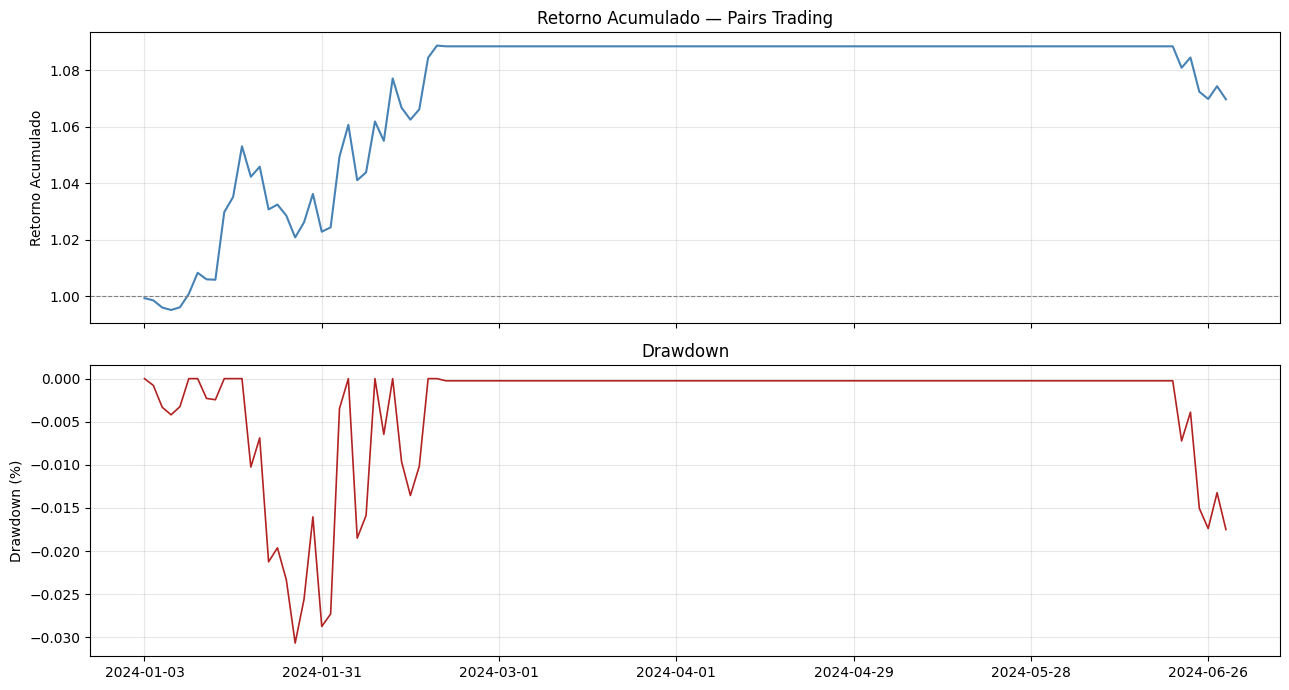

In [18]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
# ── Exportação dos resultados do Período para Excel ───────────────────────────
ARQUIVO = "periodo_4_jan2023_jun2024.xlsx"

# ── Número total de trades ────────────────────────────────────────────────────
total_trades = 0
for par in df_pares_validos['Par']:
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z = df_historico_trading[col_z]
    posicao = 0
    dias_em_posicao = 0
    meia_vida_par = int(np.ceil(
        df_pares_validos.loc[df_pares_validos['Par'] == par, 'Meia-Vida (Dias Úteis)'].values[0]
    ))
    for z_atual in z:
        nova_posicao = posicao
        if posicao == 0:
            if z_atual >= ENTRADA:
                nova_posicao = -1; dias_em_posicao = 0
            elif z_atual <= -ENTRADA:
                nova_posicao = +1; dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_atual <= SAIDA or z_atual <= -STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
            elif posicao == -1:
                if -SAIDA <= z_atual <= SAIDA or z_atual >= STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
        if nova_posicao == 0 and posicao != 0:
            total_trades += 1
            dias_em_posicao = 0
        posicao = nova_posicao

# ── Aba 5: Estatísticas resumidas ─────────────────────────────────────────────
df_estatisticas = pd.DataFrame([{
    'Período de Estimação'       : 'Jul/2021 – Jun/2022',
    'Período de Trading'         : 'Jul/2022 – Dez/2022',
    'Pares Operados'             : len(df_pares_validos),
    'Total de Trades'            : total_trades,
    'Retorno Acumulado (%)'      : round((retorno_acumulado.iloc[-1] - 1) * 100, 2),
    'Retorno Anualizado (%)'     : round(retorno_carteira.mean() * 252 * 100, 2),
    'Volatilidade Anualizada (%)': round(retorno_carteira.std() * np.sqrt(252) * 100, 2),
    'Sharpe Anualizado'          : round(sharpe, 4),
    'Maximum Drawdown (%)'       : round(mdd * 100, 2),
}])

# ── Aba 4: Retorno diário da carteira + acumulado ─────────────────────────────
df_retorno_carteira = pd.DataFrame({
    'Retorno Diário'    : retorno_carteira,
    'Retorno Acumulado' : retorno_acumulado,
    'Drawdown'          : drawdown,
})

# ── Corrige zeros negativos nos retornos por par ──────────────────────────────
df_retornos_limpo = df_retornos.round(8)

# ── Exporta para Excel com múltiplas abas ─────────────────────────────────────
with pd.ExcelWriter(ARQUIVO, engine='openpyxl') as writer:

    # Aba 1 — Pares selecionados
    df_pares_validos.to_excel(
        writer, sheet_name='1_Pares_Selecionados', index=False)

    # Aba 2 — Z-scores do período de trading
    df_historico_trading[
        [c for c in df_historico_trading.columns if '_Z-Score' in c]
    ].to_excel(writer, sheet_name='2_ZScores_Trading')

    # Aba 3 — Retornos diários por par (sem zeros negativos)
    df_retornos_limpo.to_excel(writer, sheet_name='3_Retornos_Por_Par')

    # Aba 4 — Retorno da carteira
    df_retorno_carteira.to_excel(writer, sheet_name='4_Retorno_Carteira')

    # Aba 5 — Estatísticas resumidas
    df_estatisticas.to_excel(
        writer, sheet_name='5_Estatisticas', index=False)

print(f"Arquivo '{ARQUIVO}' salvo com sucesso!")
print(f"\nAbas geradas:")
print(f"  1_Pares_Selecionados : {len(df_pares_validos)} pares")
print(f"  2_ZScores_Trading    : {len([c for c in df_historico_trading.columns if '_Z-Score' in c])} séries")
print(f"  3_Retornos_Por_Par   : {df_retornos_limpo.shape[1]} pares × {df_retornos_limpo.shape[0]} dias")
print(f"  4_Retorno_Carteira   : {len(df_retorno_carteira)} dias")
print(f"  5_Estatisticas       : {total_trades} trades no período")

Arquivo 'periodo_4_jan2023_jun2024.xlsx' salvo com sucesso!

Abas geradas:
  1_Pares_Selecionados : 4 pares
  2_ZScores_Trading    : 10 séries
  3_Retornos_Por_Par   : 4 pares × 123 dias
  4_Retorno_Carteira   : 123 dias
  5_Estatisticas       : 4 trades no período
